# $(SA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Simple_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1178,31,50,"(0.69, 1.4)","(0.051, 0.591, 0.076, -0.223)",1,1.0,"(0.063, 0.781, 0.071, -0.391)",1.0,1.0,"(0.079, 0.97, 0.064, -0.559)"
29,12,1,"(0.99, 0.1)","(-0.01, 0.05, 0.129, -0.053)",0,1.0,"(-0.009, -0.339, 0.128, 4.532)",1.0,1.0,"(-0.015, 0.004, 0.218, 1.01)"
1929,21,82,"(0.6, 0.7)","(-0.026, -0.537, 0.063, 0.649)",1,1.0,"(-0.037, -0.342, 0.076, 0.343)",0.0,1.0,"(-0.043, -0.539, 0.083, 0.698)"
1265,7,54,"(0.03, 0.4)","(-0.031, 0.204, -0.04, -0.435)",0,1.0,"(-0.027, 0.007, -0.049, -0.102)",1.0,1.0,"(-0.027, 0.205, -0.051, -0.468)"
2236,7,98,"(0.64, 1.6)","(0.046, -0.151, -0.046, 0.079)",0,1.0,"(0.043, -0.34, -0.044, 0.222)",0.0,1.0,"(0.036, -0.528, -0.04, 0.366)"
...,...,...,...,...,...,...,...,...,...,...
1271,13,54,"(0.03, 0.4)","(-0.026, 0.209, -0.063, -0.555)",1,1.0,"(-0.022, 0.408, -0.074, -0.926)",0.0,1.0,"(-0.014, 0.211, -0.092, -0.606)"
1960,22,83,"(0.79, 1.8)","(0.087, 0.341, -0.118, -0.517)",0,1.0,"(0.094, 0.152, -0.129, -0.377)",0.0,1.0,"(0.097, -0.036, -0.136, -0.239)"
1210,4,51,"(0.58, 1.0)","(0.043, -0.018, -0.027, -0.055)",1,1.0,"(0.042, 0.174, -0.029, -0.287)",0.0,1.0,"(0.046, -0.017, -0.034, -0.068)"
781,6,35,"(0.77, 0.0)","(-0.021, -0.428, 0.069, 1.378)",1,1.0,"(-0.03, -0.222, 0.097, 0.851)",1.0,1.0,"(-0.034, -0.018, 0.114, 0.344)"


In [3]:
model = Base_Line_Simple_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.06234120577573776, 0.286356121301651, 0.011...",1.627380,1.242606
1,1,"[0.06049857661128044, 0.2836702764034271, 0.01...",1.614045,1.240023
2,2,"[0.05868776515126228, 0.2810177803039551, 0.01...",1.600836,1.237457
3,3,"[0.056909285485744476, 0.27839910984039307, 0....",1.587750,1.234844
4,4,"[0.05516345426440239, 0.27581462264060974, 0.0...",1.574787,1.232226


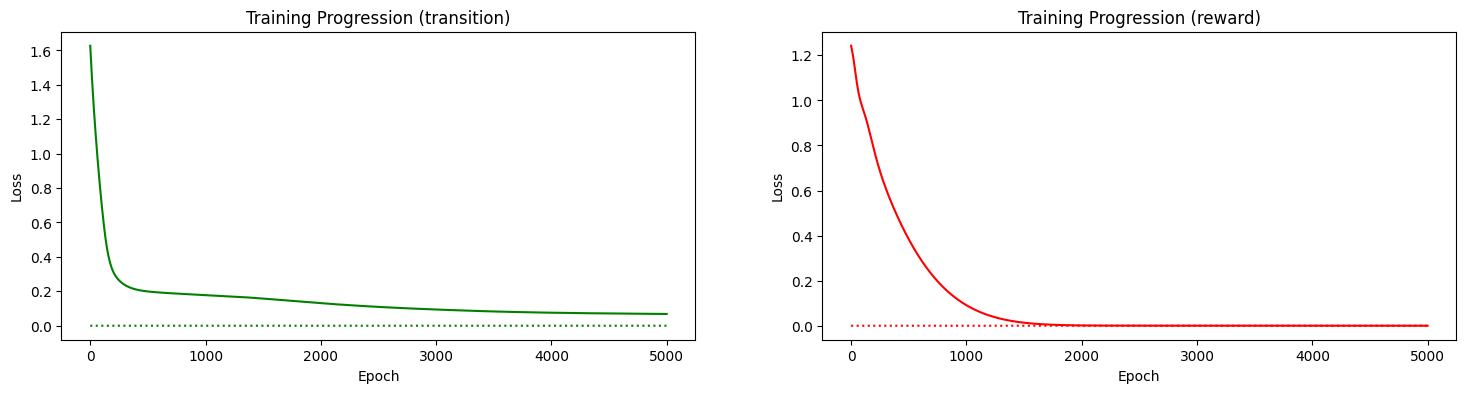

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

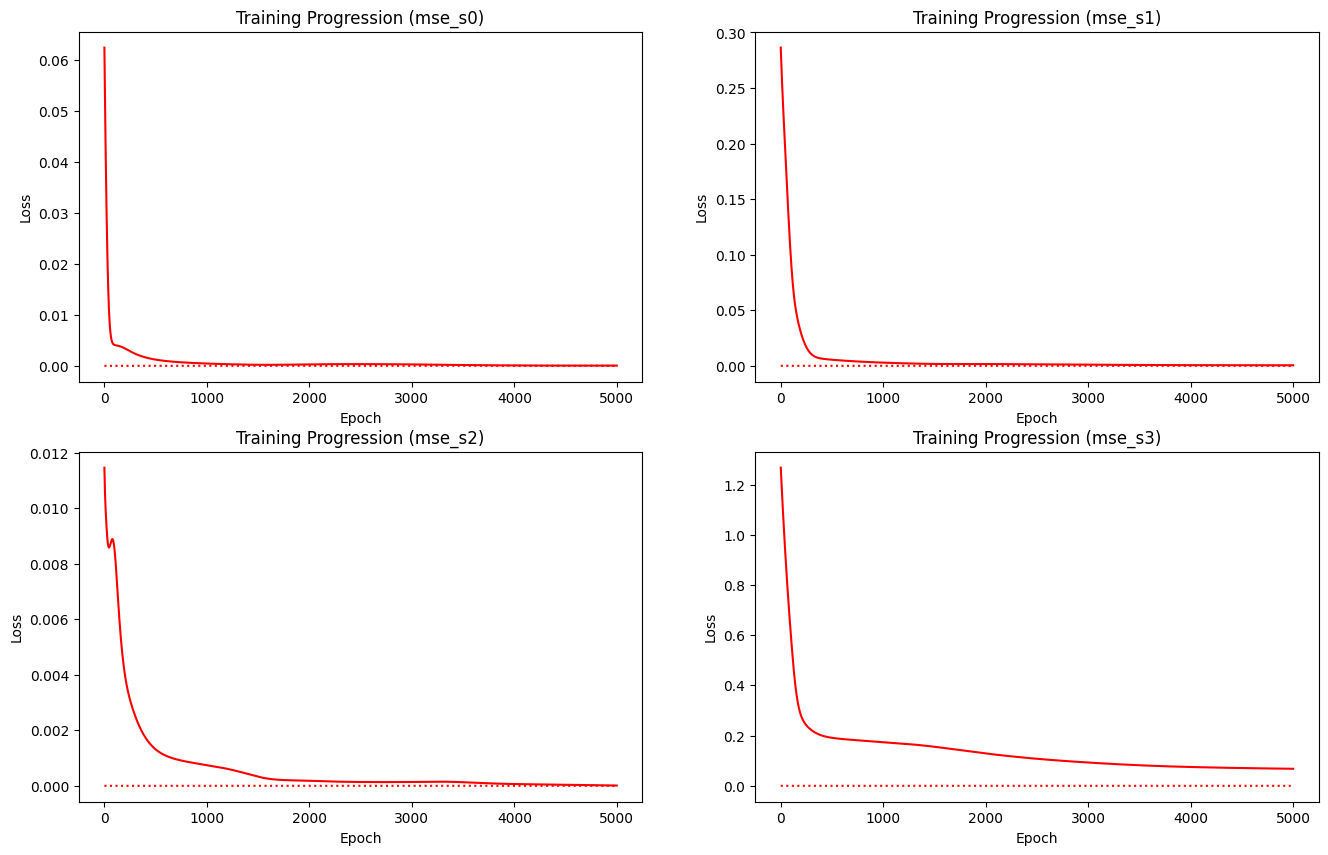

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [6]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics(p=False)
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s3,estimated_s0,estimated_s1,estimated_s2,estimated_s3,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)",...,-0.018,-0.011,-0.046,-0.016,-0.079,0.001,0.004,0.000,0.061,0.0
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)",...,-0.218,-0.009,0.143,-0.015,-0.266,0.002,0.006,0.001,0.048,0.0
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)",...,-0.418,-0.005,0.335,-0.019,-0.450,0.003,0.005,0.002,0.032,0.0
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)",...,-0.619,0.004,0.529,-0.027,-0.639,0.005,0.002,0.002,0.020,0.0
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)",...,-0.822,0.016,0.723,-0.039,-0.837,0.007,0.001,0.002,0.015,0.0


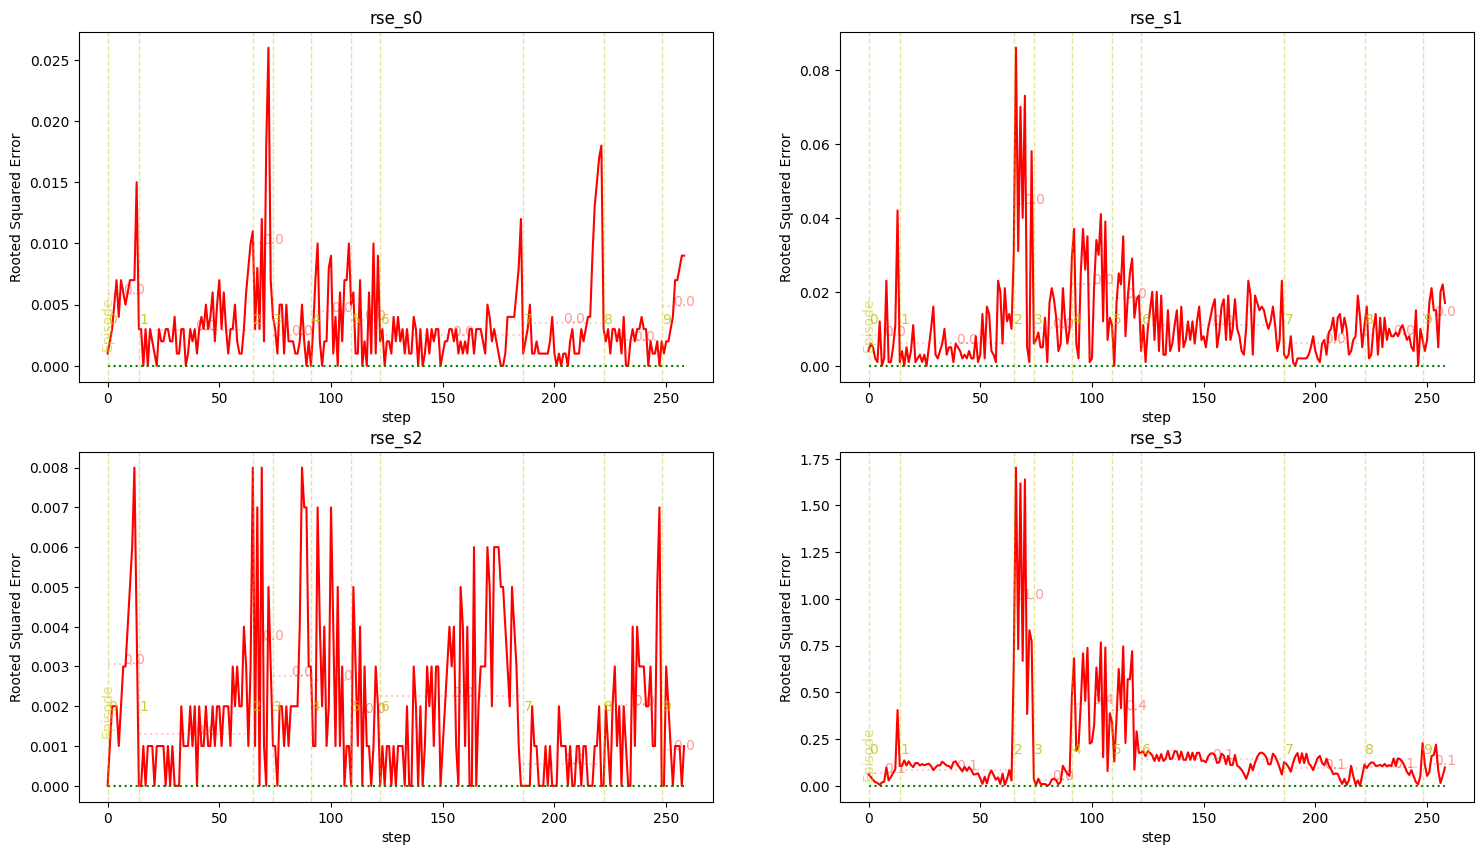

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

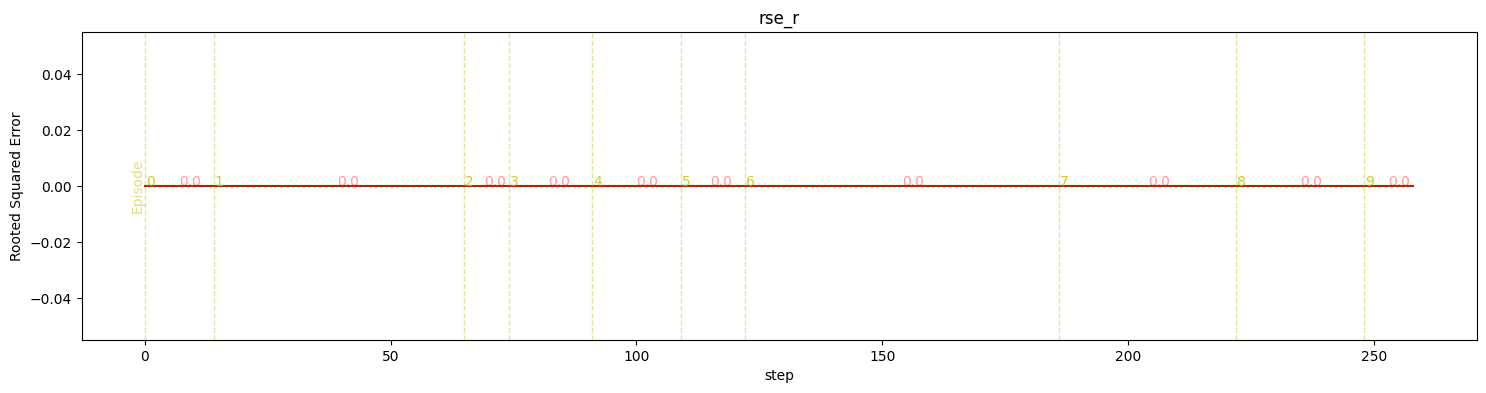

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

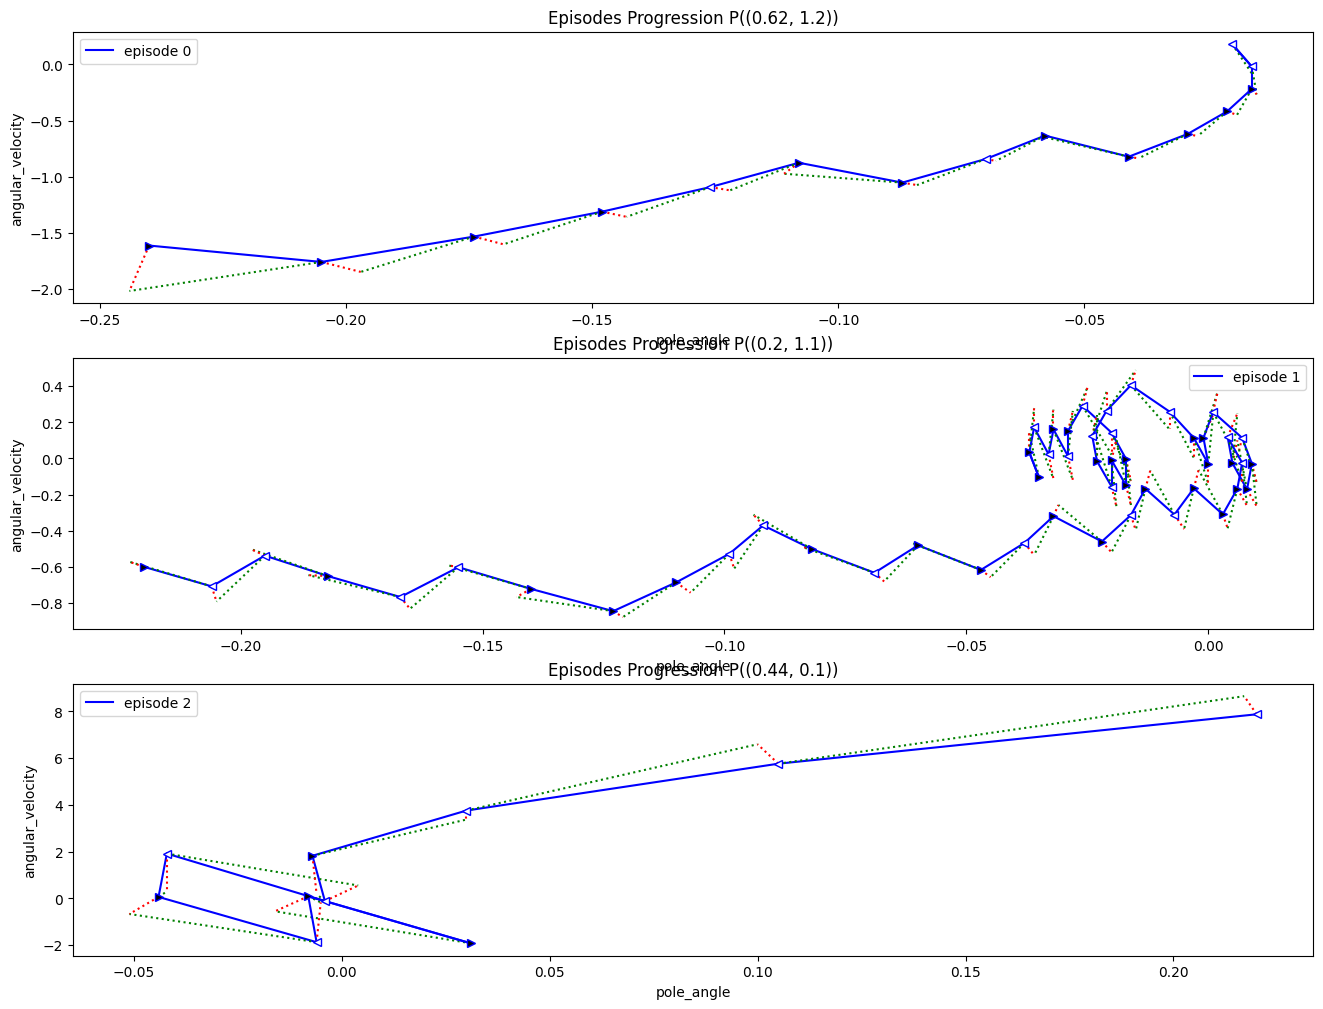

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()